Привет еще раз!  меня зовут Люман Аблаев. Сегодня я проверю твой проект.
<br> Дальнейшее общение будет происходить на "ты" если это не вызывает никаких проблем.
<br> Желательно реагировать на каждый мой комментарий ('исправил', 'не понятно как исправить ошибку', ...)
<br> Пожалуйста, не удаляй комментарии ревьюера, так как они повышают качество повторного ревью.

Комментарии будут в <font color='green'>зеленой</font>, <font color='blue'>синей</font> или <font color='red'>красной</font> рамках:

<div class="alert alert-block alert-success">
<b>Успех:</b> Если все сделано отлично
</div>

<div class="alert alert-block alert-info">
<b>Совет: </b> Если можно немного улучшить
</div>

<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Если требуются исправления. Работа не может быть принята с красными комментариями.
</div>

-------------------

Будет очень хорошо, если ты будешь помечать свои действия следующим образом:
<div class="alert alert-block alert-warning">
<b>Комментарий студента:</b> ...
</div>

<div class="alert alert-block alert-warning">
<b>Изменения:</b> Были внесены следующие изменения ...
</div>

<font color='orange' style='font-size:24px; font-weight:bold'>Общее впечатление</font>
* Приятно было проверять твою работу
- Я оставил некоторые советы, обрати на них внимание. Надеюсь они будут полезными или интересными
- Тебе удалось справиться с задачей текстов, поздравляю!
* С радостью принимаю работу и желаю удачи в дальнейшем обучении! Также напомню, что если у тебя появились вопросы - ты всегда их можешь задать мне через куратора,

<font color='green'><b>Полезные (и просто интересные) материалы:</b> \
Для работы с текстами используют и другие подходы. Например, сейчас активно используются RNN (LSTM) и трансформеры (BERT и другие с улицы Сезам, например, ELMO). НО! Они не являются панацеей, не всегда они нужны, так как и TF-IDF или Word2Vec + модели из классического ML тоже могут справляться. \
BERT тяжелый, существует много его вариаций для разных задач, есть готовые модели, есть надстройки над библиотекой transformers. Если, обучать BERT на GPU (можно в Google Colab или Kaggle), то должно быть побыстрее.\
https://huggingface.co/transformers/model_doc/bert.html \
https://t.me/renat_alimbekov \
https://colah.github.io/posts/2015-08-Understanding-LSTMs/ - Про LSTM \
https://web.stanford.edu/~jurafsky/slp3/10.pdf - про энкодер-декодер модели, этеншены\
https://pytorch.org/tutorials/beginner/transformer_tutorial.html - официальный гайд
по трансформеру от создателей pytorch\
https://transformer.huggingface.co/ - поболтать с трансформером \
Библиотеки: allennlp, fairseq, transformers, tensorflow-text — множествореализованных
методов для трансформеров методов NLP \
Word2Vec https://radimrehurek.com/gensim/models/word2vec.html 

<font color='green'>Пример BERT с GPU:
```python
%%time
from tqdm import notebook
batch_size = 2 # для примера возьмем такой батч, где будет всего две строки датасета
embeddings = [] 
for i in notebook.tqdm(range(input_ids.shape[0] // batch_size)):
        batch = torch.LongTensor(input_ids[batch_size*i:batch_size*(i+1)]).cuda() # закидываем тензор на GPU
        attention_mask_batch = torch.LongTensor(attention_mask[batch_size*i:batch_size*(i+1)]).cuda()
        
        with torch.no_grad():
            model.cuda()
            batch_embeddings = model(batch, attention_mask=attention_mask_batch)
        
        embeddings.append(batch_embeddings[0][:,0,:].cpu().numpy()) # перевод обратно на проц, чтобы в нумпай кинуть
        del batch
        del attention_mask_batch
        del batch_embeddings
        
features = np.concatenate(embeddings) 
```
Можно сделать предварительную проверку на наличие GPU.\
Например, так: ```device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")```\
Тогда вместо .cuda() нужно писать .to(device)


<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span><ul class="toc-item"><li><span><a href="#Предобработка" data-toc-modified-id="Предобработка-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Предобработка</a></span></li><li><span><a href="#Исследовательский-анализ" data-toc-modified-id="Исследовательский-анализ-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Исследовательский анализ</a></span></li></ul></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Обучение</a></span></li><li><span><a href="#Вывод:" data-toc-modified-id="Вывод:-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Вывод:</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

# Проект для «Викишоп»

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию.

Обучите модель классифицировать комментарии на позитивные и негативные. В вашем распоряжении набор данных с разметкой о токсичности правок.

Постройте модель со значением метрики качества *F1* не меньше 0.75.

**Инструкция по выполнению проекта**

1. Загрузите и подготовьте данные.
2. Обучите разные модели.
3. Сделайте выводы.

Для выполнения проекта применять *BERT* необязательно, но вы можете попробовать.

**Описание данных**

Данные находятся в файле `toxic_comments.csv`. Столбец *text* в нём содержит текст комментария, а *toxic* — целевой признак.

## Подготовка

### Предобработка

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score



<div class="alert alert-block alert-success">
<b>Успех:</b> Импорты  как всегда на месте
</div>



In [4]:
toxic_comments = pd.read_csv('/content/toxic_comments.csv', index_col=[0])

In [5]:
toxic_comments.head()

,text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


In [6]:
toxic_comments.isna().sum()

,0
text,0
toxic,0


In [7]:
toxic_comments.duplicated().sum()

np.int64(0)

В данных нет пропусков и дубликатов

### Исследовательский анализ

Визуализируем распределение токсичных и нетоксичных комментариев в датасете:

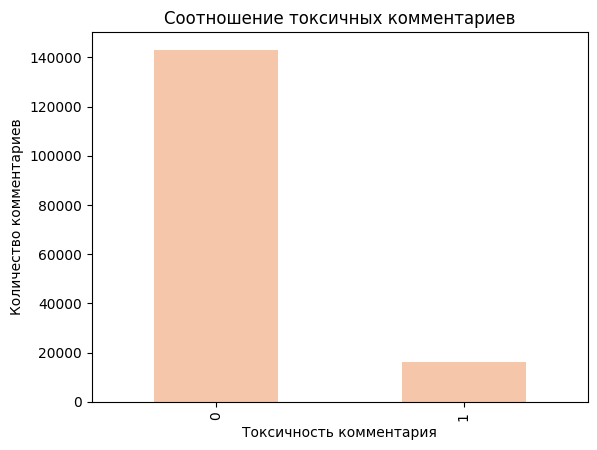

In [8]:
counts = toxic_comments['toxic'].value_counts()
counts.plot(kind='bar', color='#F5C6AA')
plt.xlabel('Токсичность комментария')
plt.ylabel('Количество комментариев')
plt.title('Соотношение токсичных комментариев')
plt.show()

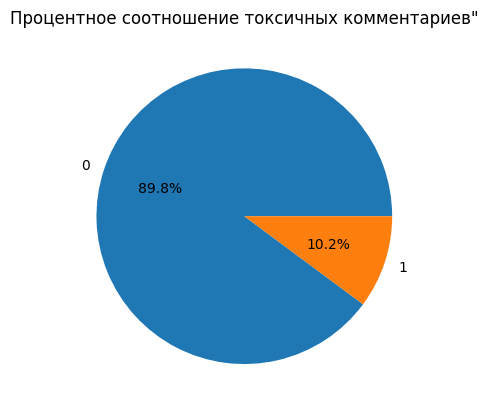

In [9]:
plt.pie(
    counts,
    labels=counts.index,
    autopct='%.1f%%')
plt.title(f'Процентное соотношение токсичных комментариев"')
plt.show()

Соотношение токсичных комментариев в данных составляет 10%, это стоит учесть при делении данных на тестовую и тренировочную выборки




<div class="alert alert-block alert-success">
<b>Успех:</b> Отлично, что обнаружен дисбаланс - это очень важно в задачах калссификации
</div>

In [10]:
# добавим новый признак "длина текста"
toxic_comments['length'] = toxic_comments['text'].astype(str).str.len()

In [11]:
# опишем длину текстов для токсичных и нетоксичных комментариев
toxic_comments.groupby('toxic')['length'].describe()

,count,mean,std,min,25%,50%,75%,max
toxic,,,,,,,,
0,143106.0,403.956585,585.914845,6.0,102.0,216.0,452.00,5000.0
1,16186.0,302.932411,618.647890,5.0,61.0,128.0,282.75,5000.0


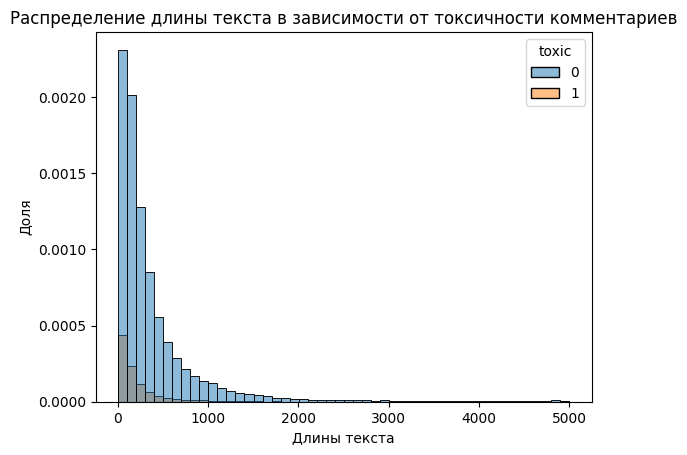

In [12]:
# визуализируем распределение длины для разных категорий текстов
sns.histplot(data=toxic_comments, x='length', hue='toxic', bins=50, kde=False, stat='density')
plt.xlabel('Длины текста')
plt.ylabel('Доля')
plt.title('Распределение длины текста в зависимости от токсичности комментариев')
plt.show()

По описанию и графику длины текстов для токсичных и нетоксичных комментариев видно, что длина токсичных комментариев в среднем меньше длины нетоксичных текстов: 303 символа против 402 в среднем, так же отличаются квартили практически в 2 раза. В обоих классах распределение с сильным хвостом вправо, но у токсичных пик смещён к более коротким текстам. Из этого можно сделать вывод, что длина текста может использоваться как дополнительная фича

In [28]:
# создадим функцию по отслеживанию топ-Nграмм
def top_ngrams(texts, ngram_range=(1, 1), top_k=20, min_df=5, stop_words=None):
    vec = CountVectorizer(
           ngram_range=ngram_range,
           min_df=min_df,
           stop_words=stop_words

       )
    X = vec.fit_transform(texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    idx = counts.argsort()[::-1][:top_k]
    return list(zip(vocab[idx], counts[idx]))

In [29]:
# напишем функцию для создания даатфрейма для сравнения Nграм токсичных и нетоксичных комментариев
def create_df_for_comparison (ngram_range=(1, 1), top_k=20, stop_words=None):
    toxic_top = top_ngrams(
        toxic_comments.query('toxic == 1')['text'],
        ngram_range=ngram_range,
        top_k=top_k,
        stop_words=stop_words)

    clean_top = top_ngrams(
        toxic_comments.query('toxic == 0')['text'],
        ngram_range=ngram_range,
        top_k=top_k,
        stop_words=stop_words)

    df = pd.DataFrame({
        'toxic_word': [w for w, c in toxic_top],
        'toxic_count': [c for w, c in toxic_top],
        'clean_word': [w for w, c in clean_top],
        'clean_count': [c for w, c in clean_top],
    })

    return df

In [30]:
create_df_for_comparison()

,toxic_word,toxic_count,clean_word,clean_count
0,you,40577,the,472709
1,the,22977,to,279130
2,to,17499,of,211371
3,and,17461,and,205964
4,is,13828,you,177203
5,of,12641,is,162112
6,fuck,9988,that,151174
7,your,9644,it,139146
8,that,9263,in,137668
9,it,9117,for,97202


Сравнение без стоп-слов малоинформативно, так как набор слов получился практическиодинаковый для обоих видов комментариев.

In [31]:
# сравним комментарии с использованием стоп-слов
create_df_for_comparison(stop_words='english')

,toxic_word,toxic_count,clean_word,clean_count
0,fuck,9988,article,55992
1,wikipedia,3919,wikipedia,44355
2,like,3798,page,43947
3,shit,3688,talk,35503
4,fucking,3320,just,25014
5,nigger,3306,like,24139
6,suck,3245,don,20630
7,ass,3001,think,18639
8,don,2840,edit,17218
9,just,2738,know,16732


С использованием стоп-слов различия в комментариях стали более заметны, в токсичных комментариях преобладают оскорбления и нецензурные слова, однако некоторые частоповторяемые слова не являются токсичными, стоит рассмотреть 2-граммы

In [32]:
# сравним комментарии с использованием стоп-слов и 2-грамм
create_df_for_comparison(ngram_range=(2,2), stop_words='english')

,toxic_word,toxic_count,clean_word,clean_count
0,fuck fuck,2959,talk page,12680
1,nigger nigger,2149,speedy deletion,4388
2,hate hate,1570,fair use,3141
3,moron hi,1474,http www,3071
4,hi moron,1472,don know,2572
5,shit shit,1149,feel free,2306
6,suck suck,1136,blocked editing,2304
7,bullshit bullshit,833,talk contribs,2209
8,faggot faggot,755,talk pages,2096
9,talk page,737,don think,2013


Отлично! По 2-граммам для токсичных комментариях можно сразу определить, что этот комментарий токсичный.

**Вывод исследовательского анализа:**

- в датасете 10% токсичных комментариев и 90% - нетоксичных;
- токсичный текст в среднем короче нетоксичного, соотвественно длину комментария можно использовать как признак;
- двуграммы со стоп-словами позволяют отличить токсичный и нетоксичный текст


<div class="alert alert-block alert-info">
    
<b>Совет:</b> 
    
    

- Неплохо было еще добавть очистку данных от мусорных символов и обработать тексты с помощью лемматизации/стемминга

	

- после очистки и лемматизации (и убрав стопслова) можно провести частотный анализ текста/[облако слов](https://habr.com/ru/post/517410/) - чтобы получить общее представление о тематике и о наиболее часто встречаемых словах в токсичных и нетоксичных твитах Кроме того графики, рисунки делают проект визуально интересней

В тренажере облако импортируем так

    !/opt/conda/bin/python -m pip install wordcloud


или

    !/opt/conda/bin/python -m pip install wordcloud==1.8.2.2


И возможно дополнительно надо будет сделать



    !pip install Pillow==8.0.0
</div>

## Обучение

In [17]:
# разделим датасет на обучающие и целевой признаки
X = toxic_comments.drop('toxic', axis=1)
y = toxic_comments['toxic']

In [18]:
# делим данные на тренировочную и тестовую выборку (стратифицируем по y, так как есть дисбаланс классов)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
# напишем пайплайн для поиска лучшей модели и метрики
preprocess = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words='english'), 'text'),
        ('len', StandardScaler(), ['length'])
    ],
    remainder='drop'
)

pipe = Pipeline([
    ('pre', preprocess),
    ('clf', LogisticRegression(max_iter=1000))
])

param_grid = {
    'pre__text__ngram_range': [(1, 1), (1, 2)],
    'pre__text__min_df': [3, 5],
    'pre__text__max_features': [50000],
    'pre__text__sublinear_tf': [True],
    'clf__C': [0.1, 1, 10],
    'clf__class_weight': [None, 'balanced']
}

grid = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=12,          # 12 случайных комбинаций * 3 фолда = 36 фиттов
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_score = grid.best_score_


Fitting 3 folds for each of 12 candidates, totalling 36 fits





<div class="alert alert-block alert-success">
<b>Успех:</b> Грамотная реализация векторизации внутри пайплайна при работе с кросс-валидацией
</div>


<div class="alert alert-block alert-info">
    
<b>Совет:</b> Неплохо было бы рассмотреть больше моделей
</div>

In [22]:
best_score

np.float64(0.7742271968142846)

In [23]:
best_model

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=50000,
                                                                  min_df=3,
                                                                  stop_words='english',
                                                                  sublinear_tf=True),
                                                  'text'),
                                                 ('len', StandardScaler(),
                                                  ['length'])])),
                ('clf', LogisticRegression(C=10, max_iter=1000))])

Метрика на тренировочный данных больше 0.75, что удовлетворяет условиям задачи, можем приступить к тестированию модели

In [25]:
y_pred = grid.predict(X_test)

In [33]:
f1_score(y_test, y_pred)

0.7843872507243906

**Вывод:** Модель LogisticRegression(C=10, max_iter=1000) дала значение метрики f1 на тестовых значений выше 0.75, а значит условие задачи выполнено


<div class="alert alert-block alert-success">
<b>Успех:</b> На тестовой выборке получено хорошее качество!
</div>


## Вывод:
В данном проекте я классифицировала комментарии по двум группам: токсичные и нетоксичные, для этого были проделаны следующие шаги:
- предобработка данных, в ходе которой не было обнаружено аномалий, пропусков и дубликатов;
- исследовательский анализ данных, в ходе которого был создан новый признак - длина текста, была обнаружена зависимость длины текста и принадлежности к классу; оценено соотношение классов и обнаружен сильный дисбаланс классов (10% токсичных комментариев); созданы функции для анализа N-грамм и создания датасета для сравнения N-грамм токсичных и нетоксичных комментариев (использование 2-грамм показало достаточную зависимость между классами);
- применяя результаты исследовательского анализы данные при разделении на выборки были стратифицированы, был создан пайплайн с гиперпараметрами для модели Логистической регрессии, с помощью RandomSearchCV была найдена лучшая модель LogisticRegression(C=10, max_iter=1000), которая дала метрику f1, равную 0.78, что оказалось даже выше, чем на тренировочной выборке и удовлетворяет условиям задачи.

P.S.: пыталась 4 дня решить задачу с помощью BERT, но ресурсов компьютера и даже Google Colab не хватило для того, чтобы решить эту задачу, так как код  с embidding-ми отрабатывал по 3-4 часа. Буду рада рекомендациям доступным GPU-платформ для решения таких задач, так как все-таки хочу добить проект с BERT и сравнить качество :) 



<div class="alert alert-block alert-info">
    
<b>Совет:</b> На коллабе доступен GPU - можешь попробовать с ним запустить 'урезанный' датасет должно сработать
</div>

## Чек-лист проверки

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Данные загружены и подготовлены
- [x]  Модели обучены
- [x]  Значение метрики *F1* не меньше 0.75
- [x]  Выводы написаны